In [1]:
import matplotlib.pyplot as plt

import scarf

scarf.configure_output(level="ERROR", progress=True)

repository = scarf.cytebase.connect("scarf_docs")
ctrl_path = repository.download_dataset(
    name="kang_15K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
stim_path = repository.download_dataset(
    name="kang_14K_ifnb-pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds_ctrl = scarf.DataStore(f"{ctrl_path}/data.zarr", nthreads=4)
ds_stim = scarf.DataStore(f"{stim_path}/data.zarr", nthreads=4)

merged_path = "scarf_datasets/kang_batch_correction.zarr"
scarf.AssayMerge(
    zarr_path=merged_path,
    assays=[ds_ctrl.RNA, ds_stim.RNA],
    names=["ctrl", "stim"],
    merge_assay_name="RNA",
    prepend_text="orig",
    reset_cell_filter=False,
    source_column="sample_id",
    overwrite=True,
).dump()
ds = scarf.DataStore(merged_path, nthreads=4)

ds.mark_hvgs(
    min_cells=10,
    top_n=2000,
    min_mean=-3,
    max_mean=2,
    max_var=6,
    show_plot=False,
)
normalized = ds.run_normalization(feat_key="hvgs")

Downloading bucket files: 56411732 / 56411732 complete

Downloading bytes: 56411732 / 56411732 complete

Downloading bucket files: 57052189 / 57052189 complete

Downloading bytes: 57052189 / 57052189 complete

Writing merged assay: 8 / 8 complete

Computing RNA initialization statistics: 7 / 7 complete

Computing RNA feature statistics: 35 / 35 complete

Writing data: 2 / 2 complete

In [2]:
pca_full = ds.run_pca(normalized, dims=25)
ds.build_embedding_initialization(pca_full)
ann = ds.build_ann_index(pca_full)
neighbors = ds.query_neighbors(ann, k=21)
graph = ds.build_connectivity_map(neighbors)
ds.run_umap(
    graph,
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True,
    label="uncorrected_UMAP",
)

Fitting PCA: 2 / 2 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 2 / 2 complete

Loading kmeans coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Training UMAP: 250 / 250 complete

ArtifactRef(assay='RNA', kind='embedding', artifact_id='49095f398a33...')

In [3]:
ds.cells.insert(
    column_name="is_ctrl",
    values=ds.cells.fetch_all("sample_id") == "ctrl",
    overwrite=True,
)

pca_partial = ds.run_pca(
    normalized,
    dims=25,
    pca_cell_key="is_ctrl",
)
ds.build_embedding_initialization(pca_partial)
ann = ds.build_ann_index(pca_partial)
neighbors = ds.query_neighbors(ann, k=21)
partial_graph = ds.build_connectivity_map(neighbors)
ds.run_umap(
    partial_graph,
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True,
    label="partial_UMAP",
)

Fitting PCA: 2 / 2 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 2 / 2 complete

Loading kmeans coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Training UMAP: 250 / 250 complete

ArtifactRef(assay='RNA', kind='embedding', artifact_id='540c9cb2a171...')

In [4]:
pca_full = ds.run_pca(normalized, dims=25)
corrected = ds.run_harmony(["sample_id"], pca_full)
ds.build_embedding_initialization(pca_full)
ann = ds.build_ann_index(corrected)
neighbors = ds.query_neighbors(ann, k=21)
harmony_graph = ds.build_connectivity_map(neighbors)
ds.run_umap(
    harmony_graph,
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True,
    label="harmony_UMAP",
)

Loading uncorrected latent dimensions: 1 / 1 complete

Harmonizing batches: 50 / 50 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Training UMAP: 250 / 250 complete

ArtifactRef(assay='RNA', kind='embedding', artifact_id='ed5756ebfe86...')

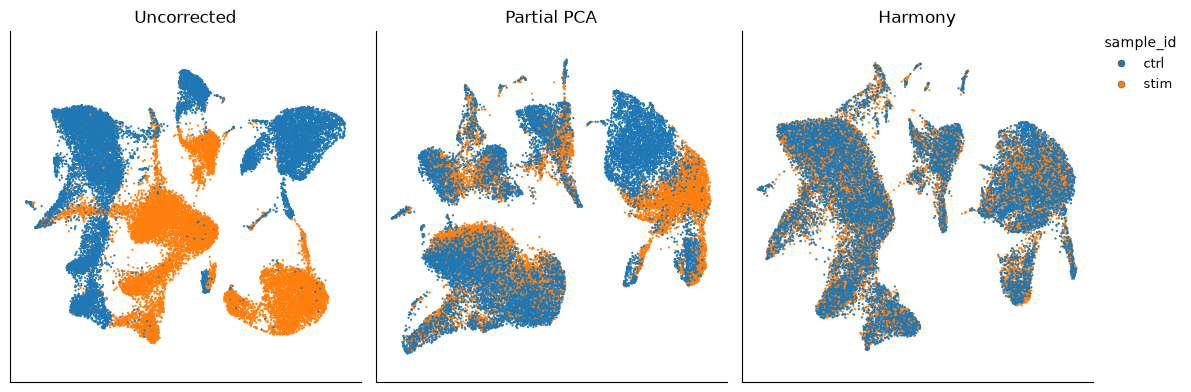

In [5]:
layout_comparisons = (
    ("Uncorrected", "RNA_uncorrected_UMAP"),
    ("Partial PCA", "RNA_partial_UMAP"),
    ("Harmony", "RNA_harmony_UMAP"),
)


def compare_graphs(color_by):
    figure, axes = plt.subplots(1, 3, figsize=(12, 4))
    for index, (axis, (title, layout_key)) in enumerate(
        zip(axes, layout_comparisons, strict=True)
    ):
        ds.plots.embedding(
            layout_key=layout_key,
            color_by=color_by,
            legend_loc="right",
            show_legend=index == 2,
            show_titles=False,
            target=axis,
            show=False,
        )
        axis.set_title(title)
    figure.tight_layout()
    return figure


compare_graphs("sample_id");

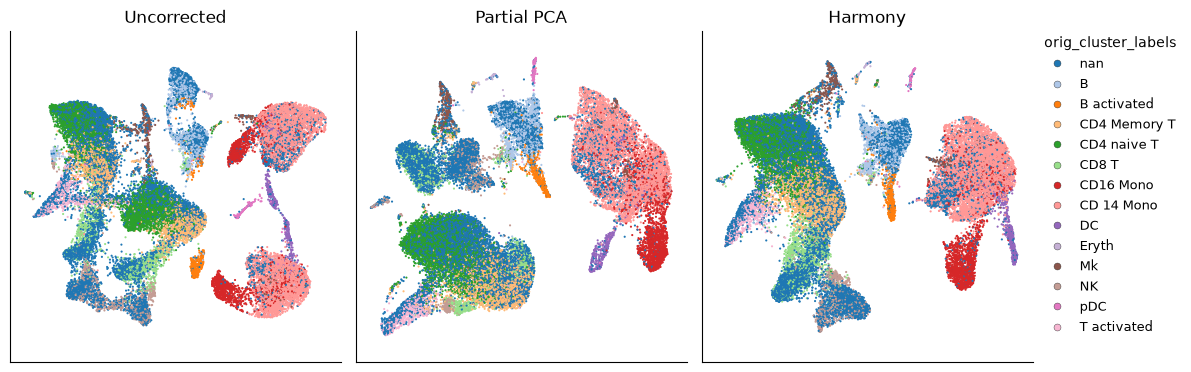

In [6]:
compare_graphs("orig_cluster_labels");